# Stage 10a — Linear Regression

## 1. Goal

Fit a baseline regression, diagnose its residuals, and decide whether it is trustworthy.

In [1]:
from pathlib import Path
import os

import ipynbname

try:
    HOMEWORK_DIR = Path(ipynbname.path()).resolve().parent
except (FileNotFoundError, IndexError):
    HOMEWORK_DIR = Path.cwd().resolve()
    candidate = HOMEWORK_DIR / "homework" / "homework10a"
    if candidate.is_dir():
        HOMEWORK_DIR = candidate
os.chdir(HOMEWORK_DIR)
print("Working from:", HOMEWORK_DIR.name)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

Working from: homework10a


## 2. Data and split

The synthetic outcome has a small curved component. The first model intentionally uses only the two original predictors.

In [2]:
x1 = rng.normal(size=500)
x2 = rng.normal(size=500)
noise = rng.normal(scale=1.2, size=500)
y = 3.0 * x1 - 2.0 * x2 + 0.8 * x1**2 + noise
data = pd.DataFrame({"x1": x1, "x2": x2, "y": y})

train, test = train_test_split(data, test_size=0.20, random_state=RANDOM_SEED)
model = LinearRegression().fit(train[["x1", "x2"]], train["y"])
fitted = model.predict(test[["x1", "x2"]])
residuals = test["y"].to_numpy() - fitted

baseline_metrics = pd.Series({
    "r2": r2_score(test["y"], fitted),
    "rmse": mean_squared_error(test["y"], fitted) ** 0.5,
}, name="baseline")
baseline_metrics

r2      0.870019
rmse    1.353822
Name: baseline, dtype: float64

## 3. Residual diagnostics

Residuals should have no systematic relationship with fitted values or their own lag, roughly constant spread, and an approximately normal center.

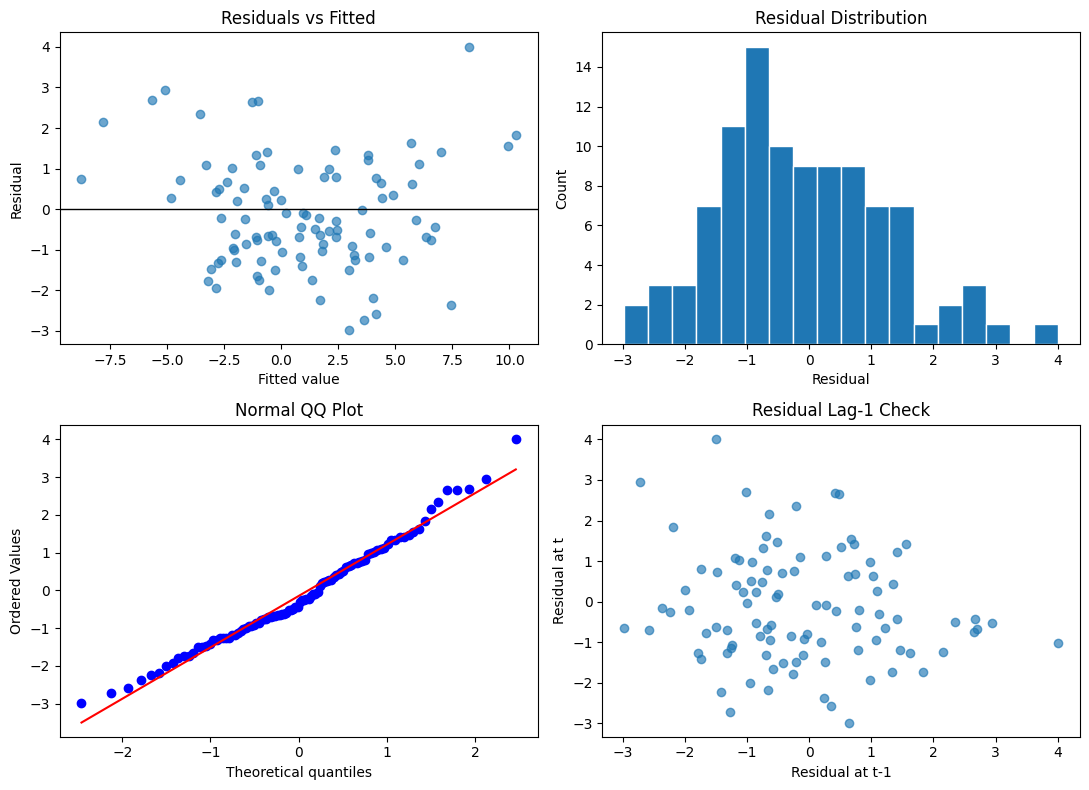

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0, 0].scatter(fitted, residuals, alpha=0.65)
axes[0, 0].axhline(0, color="black", linewidth=1)
axes[0, 0].set(title="Residuals vs Fitted", xlabel="Fitted value", ylabel="Residual")

axes[0, 1].hist(residuals, bins=18, edgecolor="white")
axes[0, 1].set(title="Residual Distribution", xlabel="Residual", ylabel="Count")

stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Normal QQ Plot")

axes[1, 1].scatter(residuals[:-1], residuals[1:], alpha=0.65)
axes[1, 1].set(title="Residual Lag-1 Check", xlabel="Residual at t-1", ylabel="Residual at t")
fig.tight_layout()
plt.show()

The residual-vs-fitted plot shows curvature, so the linearity assumption is weak. The spread is fairly stable, the histogram and QQ plot are acceptable in the center, and the lag plot shows no strong dependence. Random sampling supports independence, but it does not prove it for real time-series data.

## 4. Optional transformed feature

Adding $x_1^2$ is still linear regression because the model remains linear in its estimated coefficients.

In [4]:
train_extended = train.assign(x1_squared=train["x1"] ** 2)
test_extended = test.assign(x1_squared=test["x1"] ** 2)
extended_features = ["x1", "x2", "x1_squared"]

extended_model = LinearRegression().fit(train_extended[extended_features], train_extended["y"])
extended_fitted = extended_model.predict(test_extended[extended_features])
comparison = pd.DataFrame({
    "baseline": baseline_metrics,
    "with_x1_squared": {
        "r2": r2_score(test["y"], extended_fitted),
        "rmse": mean_squared_error(test["y"], extended_fitted) ** 0.5,
    },
}).T
comparison

,r2,rmse
baseline,0.870019,1.353822
with_x1_squared,0.908886,1.133477


## 5. Conclusion

I would not trust the baseline for explanation because its residual curvature reveals a missing relationship. The transformed model is more useful because it matches the known data structure and improves both $R^2$ and RMSE. For real decisions, I would still test stability on new data and check whether the transformation has a defensible interpretation.